# AKLS Hybrid Propagation Model v1

このNotebookは、AKLSの膜ろ過プロセスを、**機構式（何が何を生むか）**と**確率モデル（その関係の不確実性）**を組み合わせて予測する小型のHybrid Propagation Modelである。

## このNotebookで行うこと

```text
実験データ
  -> 列名・単位・runを統一
  -> run内の欠測を補間し、遷移区間を作る
  -> q-rate（抗体産生、fouling、sieving低下の速度）を推定
  -> 状態を時間方向へ累積伝播
  -> TMP / Transmission / Filtrate antibodyを予測
  -> MCMCの信用区間と診断図で妥当性を確認
```

### v1で扱う状態と観測

- `Feed antibody`: VCD・Viabilityを外生ドライバーとして抗体産生rate `q_ab`から伝播する
- `Fouling state`: fouling rate `q_foul`を時間積分した潜在状態
- `Transmission`: sieving loss rate `q_sieve_loss`により低下する膜透過性
- `TMP`: 背圧負荷とfouling stateから予測する観測値
- `Filtrate antibody`: `Feed antibody × Transmission`で生成する下流の目的変数

### v1でまだ扱わないもの

- Glucose / Lactate / Glnなどの代謝物収支
- VCD自体の増殖・死滅ODE
- 反応器体積の完全な収支
- GP / NNによるq-rate関数

VCDとViabilityは観測済みの外生ドライバーとして使い、`q_Ab`、`q_foul`、`q_sieving_loss`をデータから推定する。出力は観測範囲内の確率的予測であり、未検証条件への外挿や因果関係の証明ではない。

In [ ]:
# このセルは、必要なパッケージと推奨バージョンを確認するための案内である。
# 必要に応じて最初に実行してください。
# ArviZ 1.x環境で `cannot import name 'concat' from 'arviz'` が出る場合は、下記のようにarviz<1へ戻してください。
# %pip install -r akls_hybrid_propagation_v1_requirements.txt
# または:
# %pip install 'pymc>=5.15,<6' 'arviz>=0.17,<1.0' pandas openpyxl matplotlib ipywidgets japanize-matplotlib netcdf4

### セルの役割

このセルは、必要な依存パッケージと推奨バージョンを確認するための案内である。通常はコードを変更せず、環境エラーが出た場合だけインストールコマンドを実行する。

In [1]:
# このセルは、ライブラリ、入力探索先、出力先、MCMC実行条件を初期化する。
from __future__ import annotations

from pathlib import Path
import re
import datetime as dt
import traceback
import warnings
import jax
import jaxlib
import numpyro

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

try:
    import japanize_matplotlib  # noqa: F401
    JAPANESE_FONT_AVAILABLE = True
except Exception:
    JAPANESE_FONT_AVAILABLE = False

try:
    import arviz as az
    import pymc as pm
    import pytensor.tensor as pt
    PYMC_AVAILABLE = True
except Exception as exc:
    PYMC_AVAILABLE = False
    PM_IMPORT_ERROR = exc

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
np.set_printoptions(suppress=True, precision=4)

# 実行場所に応じて入力ファイルを探索する。
DATA_DIR_CANDIDATES = [
    Path.cwd(),
    Path.cwd() / "user_files",
    Path.cwd().parent / "user_files",
    Path.cwd().parent,
    Path("/mnt/data"),
]
DATA_DIR_CANDIDATES = [p for p in DATA_DIR_CANDIDATES if p.exists()]

OUTPUT_DIR = Path.cwd() / "akls_hybrid_propagation_v1_results"
if Path("/mnt/data").exists() and Path.cwd() == Path("/mnt/data"):
    OUTPUT_DIR = Path("/mnt/data") / "akls_hybrid_propagation_v1_results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 初回は小さく動作確認し、最終実行で draws/tune/chains を増やす。
draws = 1000
tune = 1000
chains = 4
cores = min(chains, 4)
target_accept = 0.92
random_seed = 123
hdi_prob = 0.95
RUN_SAMPLING = True
USE_TRANSMISSION_LIKELIHOOD = False  # Filtrate AbとTransmissionの二重カウントを避けるため、既定はFalse。
NUTS_SAMPLER = "numpyro"  # numpyroが入っている環境なら "numpyro" へ変更可。


print(f"JAPANESE_FONT_AVAILABLE={JAPANESE_FONT_AVAILABLE}")
print(f"PYMC_AVAILABLE={PYMC_AVAILABLE}")
if not PYMC_AVAILABLE:
    print("PyMC import error:", repr(PM_IMPORT_ERROR))
print("探索ディレクトリ:")
for p in DATA_DIR_CANDIDATES:
    print("-", p.resolve())
print("OUTPUT_DIR=", OUTPUT_DIR.resolve())

c:\Users\a1049994\AppData\Local\miniforge3\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`


JAPANESE_FONT_AVAILABLE=True
PYMC_AVAILABLE=True
探索ディレクトリ:
- D:\Users\a1049994\CVC\AKLS
- D:\Users\a1049994\CVC\AKLS\user_files
- D:\Users\a1049994\CVC
OUTPUT_DIR= D:\Users\a1049994\CVC\AKLS\akls_hybrid_propagation_v1_results


### セルの役割

このセルは、ライブラリを読み込み、入力ファイルの探索先、出力フォルダー、MCMCの実行条件を設定する。ここで設定した`draws`・`tune`・`chains`と実行フラグが、後続セル全体の実行方法を決める。

## 1. AKLSデータの読み込み

このセクションの目的は、入力データの形式がCSV、Master Excel、Raw Excelのいずれでも、後続のモデルが同じ列名・単位・run構造で扱える状態にすることである。

入力探索の優先順位は次の通り。

1. `AKLS_cleaned_records.csv`
2. `AKLS_master_dataset.xlsx`
3. Raw Excelファイル `*_Perfusion*.xlsx`

Raw Excelを読む場合は、ヘッダー行を検出し、複数行ヘッダーを1行の列名へまとめ、runの運転条件（shear rate / LMH）をファイル名から付与する。ここではまだモデル推定を行わず、データの入口を整える。

In [2]:
def clean_text(value) -> str:
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return ""
    text = str(value).replace("\n", " ").strip()
    text = re.sub(r"\s+", " ", text)
    return text


def slug(text: str) -> str:
    text = clean_text(text).lower()
    text = text.replace("μ", "u").replace("²", "2")
    text = re.sub(r"[^a-z0-9]+", "_", text)
    text = re.sub(r"_+", "_", text).strip("_")
    return text or "unnamed"


def make_unique(names: list[str]) -> list[str]:
    seen = {}
    out = []
    for name in names:
        base = name or "unnamed"
        count = seen.get(base, 0)
        out.append(base if count == 0 else f"{base}_{count + 1}")
        seen[base] = count + 1
    return out


def choose_record_sheet(path: Path) -> str:
    xls = pd.ExcelFile(path)
    candidates = [
        sheet for sheet in xls.sheet_names
        if "record" in sheet.lower()
        and "guide" not in sheet.lower()
        and "blank" not in sheet.lower()
    ]
    if not candidates:
        raise ValueError(f"No record sheet found in {path.name}: {xls.sheet_names}")
    return candidates[0]


def detect_header_row(raw: pd.DataFrame) -> int:
    for idx, row in raw.iterrows():
        values = [clean_text(value).lower() for value in row.tolist()]
        if any("elapsed time" in value for value in values):
            return int(idx)
    preview = raw.head(6).map(clean_text) if hasattr(raw, "map") else raw.head(6).applymap(clean_text)
    raise ValueError(
        "Could not find header row containing 'Elapsed time'. "
        f"First rows were:\n{preview.to_string(index=False)}"
    )


def make_column_names(raw: pd.DataFrame, header_idx: int) -> list[str]:
    group = raw.iloc[header_idx - 1].tolist() if header_idx > 0 else [""] * raw.shape[1]
    sub = raw.iloc[header_idx].tolist()
    group_filled = []
    current = ""
    for value in group:
        cleaned = clean_text(value)
        if cleaned:
            current = cleaned
        group_filled.append(current)
    names = []
    for i, (g, s) in enumerate(zip(group_filled, sub)):
        g = clean_text(g)
        s = clean_text(s)
        if not g and not s:
            name = f"unnamed_{i}"
        elif g and s:
            name = f"{g} | {s}"
        else:
            name = g or s
        names.append(name)
    return make_unique(names)


def parse_experiment_metadata(path: Path) -> dict:
    name = path.stem
    shear_match = re.search(r"she[ae]r_rate_(\d+)", name, flags=re.I)
    lmh_match = re.search(r"LMH_(\d+)", name, flags=re.I)
    record_match = re.search(r"^(\d+)_Perfusion", name, flags=re.I)
    run = record_match.group(1) if record_match else name
    shear = int(shear_match.group(1)) if shear_match else np.nan
    lmh = int(lmh_match.group(1)) if lmh_match else np.nan
    return {
        "source_file": path.name,
        "run_id": run,
        "experiment": run,
        "shear_rate_lmh": shear,
        "shear_rate": shear,
        "lmh_group": lmh,
        "lmh_level": lmh,
        "condition_label": f"shear={shear}, LMH={lmh}",
        "condition": f"{shear} shear / LMH {lmh}",
    }


def to_number(value):
    if value is None:
        return np.nan
    if isinstance(value, (int, float, np.integer, np.floating)):
        if pd.isna(value):
            return np.nan
        return float(value)
    if isinstance(value, dt.timedelta):
        return value.total_seconds() / 3600
    if isinstance(value, dt.time):
        return value.hour + value.minute / 60 + value.second / 3600
    text = str(value).strip().replace("−", "-")
    if text in {"", "-", "nan", "None"}:
        return np.nan
    range_match = re.fullmatch(r"\s*(\d+(?:\.\d+)?)\s*-\s*(\d+(?:\.\d+)?)\s*", text)
    if range_match:
        return (float(range_match.group(1)) + float(range_match.group(2))) / 2
    num_match = re.search(r"[-+]?\d+(?:\.\d+)?", text.replace(",", ""))
    if num_match:
        return float(num_match.group(0))
    return np.nan

### セルの役割

このセルは、Raw Excelを読める形へ変換するための汎用関数群を定義する。ヘッダー検出、列名の標準化、ファイル名からのrun条件抽出、文字列から数値への変換を担当し、まだPyMCモデルは実行しない。

In [3]:
def standard_name(column, occurrence: dict[str, int]) -> str | None:
    key = slug(clean_text(column))

    if "elapsed_time_h" in key:
        return "elapsed_h"
    if "feed_filtrate" in key:
        return "sampling_volume"
    if "circulation" in key and "ml_min" in key:
        return "circulation_mL_min"
    if "circulation" in key and "rpm" in key:
        return "circulation_rpm"
    if "filtration" in key and "ul_min" in key:
        return "filtration_uL_min"
    if "filtration_amount" in key and "l_m2" in key:
        return "cumulative_filtrate_l_m2"
    if "flow_of_initial" in key or key.endswith("flow_rate_flow"):
        return "flow_pct_initial"
    if "filtration_flow_ratio_cumulative" in key:
        return "filtration_flow_cumulative_pct"
    if "flow_ratio" in key:
        return "flow_ratio_pct"
    if "pressure_in" in key:
        return "pressure_in_kPa"
    if "pressure_out" in key:
        return "pressure_out_kPa"
    if "back_pressure" in key:
        return "back_pressure_kPa"
    if key.endswith("tmp") or "pressure_kpa_tmp" in key:
        return "tmp_kPa"
    if "temperature" in key and "degc" in key:
        return "temperature_C"
    if "cell_density" in key:
        if "matsuda" in key:
            return "cell_density_matsuda_1e5_mL"
        if "cho" in key:
            return "cell_density_cho_1e5_mL"
        return "cell_density_1e5_mL"
    if "viability" in key:
        if "matsuda" in key:
            return "viability_matsuda_pct"
        if "cho" in key:
            return "viability_cho_pct"
        return "viability_pct"
    if "medium_components_glc" in key:
        return "glc_g_L"
    if "medium_components_glu" in key:
        return "glu_mmol_L"
    if "medium_components_gln" in key:
        return "gln_mmol_L"
    if "medium_components_lln" in key:
        return "lln_g_L"
    if "antibody_concentration_feed" in key:
        return "feed_antibody_g_L"
    if "antibody_concentration_filtrate" in key:
        return "filtrate_antibody_g_L"
    if "transmission" in key and "cumulative" not in key:
        return "transmission_pct"
    if "cumulative_transmission" in key:
        return "cumulative_transmission_pct"
    if "antibody_concentration_g_m2" in key or re.search(r"antibody_concentration_g_m2_?\d*$", key):
        occurrence["antibody_g_m2"] = occurrence.get("antibody_g_m2", 0) + 1
        return f"antibody_g_m2_{occurrence['antibody_g_m2']}"
    if "turbidity_od600_feed" in key:
        return "turbidity_feed_od600"
    if "turbidity_od600_filtrate" in key:
        return "turbidity_filtrate_od600"
    if "plate_reader" in key:
        return "turbidity_plate_reader"
    if "ldh_activity" in key:
        return "ldh_activity_unit"
    return None


def load_record(path: Path) -> pd.DataFrame:
    sheet = choose_record_sheet(path)
    raw = pd.read_excel(path, sheet_name=sheet, header=None, engine="openpyxl")
    header_idx = detect_header_row(raw)
    columns = make_column_names(raw, header_idx)
    columns = make_unique([clean_text(c) or f"unnamed_{i}" for i, c in enumerate(columns)])
    data = raw.iloc[header_idx + 1:].copy()
    data.columns = columns
    data = data.dropna(how="all").reset_index(drop=True)
    data.insert(0, "row_label", data.iloc[:, 0].astype(object))
    data = data.drop(columns=[data.columns[1]])
    data = data[data["row_label"].astype(str).str.lower().ne("example")].copy()

    occurrence = {}
    rename_map = {}
    for col in data.columns:
        if col == "row_label":
            continue
        new = standard_name(col, occurrence)
        if new:
            rename_map[col] = new

    tidy = data.rename(columns=rename_map)
    metadata = parse_experiment_metadata(path)
    for key, value in metadata.items():
        tidy[key] = value
    tidy["record_sheet"] = sheet

    if "elapsed_h" in tidy.columns:
        tidy["elapsed_h"] = tidy["elapsed_h"].map(to_number)
        tidy = tidy[tidy["elapsed_h"].notna()].copy()

    numeric_exclusions = {"row_label", "sampling_volume", "source_file", "condition", "condition_label", "record_sheet"}
    numeric_candidates = [c for c in tidy.columns if c not in numeric_exclusions]
    for col in numeric_candidates:
        tidy[col] = tidy[col].map(to_number)

    tidy = tidy.sort_values(["run_id", "elapsed_h"]).reset_index(drop=True)
    return tidy


def load_all_records(files: list[Path]) -> pd.DataFrame:
    frames = []
    for path in files:
        try:
            frames.append(load_record(path))
        except Exception as exc:
            print(f"Skipped {path.name}: {exc}")
            traceback.print_exc(limit=2)
    if not frames:
        raise ValueError("No usable Excel records were loaded.")
    return pd.concat(frames, ignore_index=True, sort=False)



def coalesce_duplicate_columns(frame: pd.DataFrame) -> pd.DataFrame:
    """同名列が複数ある場合、左から順にfirst non-nullで統合する。"""
    if not frame.columns.duplicated().any():
        return frame
    out = frame.loc[:, ~frame.columns.duplicated()].copy()
    for name in frame.columns[frame.columns.duplicated()].unique():
        cols = frame.loc[:, frame.columns == name]
        out[name] = cols.bfill(axis=1).iloc[:, 0]
    return out


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    aliases = {
        "tmp_kPa": "tmp_kpa", "TMP_kPa": "tmp_kpa", "tmp_KPa": "tmp_kpa",
        "back_pressure_kPa": "back_pressure_kpa",
        "feed_antibody_g_L": "feed_antibody_g_l",
        "filtrate_antibody_g_L": "filtrate_antibody_g_l",
        "filtration_amount_L_m2": "cumulative_filtrate_l_m2",
        "experiment": "run_id", "lmh_level": "lmh_group",
        "shear_rate": "shear_rate_lmh", "condition": "condition_label",
        "cell_density_cho_1e5_mL": "vcd_cho_1e5_cells_ml",
        "cell_density_matsuda_1e5_mL": "vcd_matsuda_1e5_cells_ml",
        "cell_density_1e5_mL": "vcd_1e5_cells_ml",
        "viability_cho_pct": "viability_cho_pct",
        "viability_matsuda_pct": "viability_matsuda_pct",
        "viability_pct": "viability_pct",
        "turbidity_feed_od600": "turbidity_feed_od600",
        "filtration_uL_min": "filtration_ul_min",
        "circulation_mL_min": "circulation_ml_min",
    }
    result = df.copy()
    for old, new in aliases.items():
        if old not in result.columns or old == new:
            continue
        if new in result.columns:
            # raw loaderなどで既にcanonical列がある場合は、既存列を優先し欠測だけoldで補う。
            result[new] = result[new].combine_first(result[old])
            result = result.drop(columns=[old])
        else:
            result = result.rename(columns={old: new})
    result = coalesce_duplicate_columns(result)
    if "run_id" not in result.columns and "source_file" in result.columns:
        result["run_id"] = result["source_file"].astype(str)
    if "row_number" not in result.columns:
        result["row_number"] = result.groupby("run_id", dropna=False).cumcount()
    if "condition_label" not in result.columns:
        result["condition_label"] = result["run_id"].astype(str)
    return result

def find_input_data() -> tuple[pd.DataFrame, str]:
    # 1. CSV優先
    for d in DATA_DIR_CANDIDATES:
        candidates = sorted(d.glob("AKLS_cleaned_records.csv"))
        if candidates:
            return pd.read_csv(candidates[0]), str(candidates[0])
    # 2. マスターExcel
    for d in DATA_DIR_CANDIDATES:
        candidates = sorted(d.glob("AKLS_master_dataset.xlsx"))
        if candidates:
            return pd.read_excel(candidates[0], sheet_name="Master_Data"), str(candidates[0])
    # 3. Raw Excel
    for d in DATA_DIR_CANDIDATES:
        files = sorted(d.glob("*Perfusion*.xlsx"))
        if files:
            return load_all_records(files), f"raw Excel files in {d} ({len(files)} files)"
    raise FileNotFoundError("AKLS_cleaned_records.csv, AKLS_master_dataset.xlsx, or raw *_Perfusion*.xlsx files were not found.")

raw_df, data_source = find_input_data()
df = normalize_columns(raw_df)
print("data_source:", data_source)
print("shape:", df.shape)
display(df.head())

data_source: d:\Users\a1049994\CVC\AKLS\AKLS_cleaned_records.csv
shape: (186, 55)


,row_label,elapsed_h,sampling_volume,circulation_ml_min,circulation_rpm,filtration_ul_min,Flow rate | cm,Flow rate | time,cumulative_filtrate_l_m2,Filtration amount | Cumulative,pressure_in_kPa,pressure_out_kPa,back_pressure_kpa,tmp_kpa,temperature_C,vcd_cho_1e5_cells_ml,viability_cho_pct,vcd_matsuda_1e5_cells_ml,viability_matsuda_pct,glc_g_L,glu_mmol_L,gln_mmol_L,lln_g_L,feed_antibody_g_l,filtrate_antibody_g_l,transmission_pct,antibody_g_m2_1,antibody_g_m2_2,cumulative_transmission_pct,turbidity_feed_od600,turbidity_filtrate_od600,turbidity_plate_reader,ldh_activity_unit,LDH,LDH_2,LDH_3,LDH_4,LDH_5,source_file,run_id,shear_rate_lmh,lmh_group,condition_label,record_sheet,Date removed,Time,flow_pct_initial,Flow rate | %,vcd_1e5_cells_ml,viability_pct,LDH_6,filtration_flow_cumulative_pct,flow_ratio_pct,Turbidity OD600,row_number
0,Filtration start,0.0,"2.0, 0.0",8.05,920.0,NaN,NaN,NaN,0.000000,NaN,1.5,-1.0,-0.4,0.7,9.4,146.0,94.8,NaN,NaN,3.14,0.48,0.32,0.50,0.496091,NaN,NaN,NaN,NaN,NaN,1.225,NaN,1.2252,497.992,574.005,535.9985,53.749308,NaN,0.31,01_Perfusion-shear_rate_500_LMH_1.xlsx,01_Perfusion-shear_rate_500_LMH_1,500.0,1.0,500 shear / LMH 1,01-record,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,NaN,2.0,NaN,8.05,950.0,NaN,NaN,NaN,NaN,NaN,1.3,-1.3,-0.8,0.8,4.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,01_Perfusion-shear_rate_500_LMH_1.xlsx,01_Perfusion-shear_rate_500_LMH_1,500.0,1.0,500 shear / LMH 1,01-record,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,NaN,17.5,"1.5, 1.5",8.05,960.0,5.110792,2.3,0.566111,17.887771,101.693805,1.4,-1.3,-1.0,1.1,3.6,137.0,93.5,NaN,NaN,3.16,0.50,0.28,0.56,0.494442,0.488015,98.700124,8.859209,8.729494,98.535814,NaN,0.006,0.0055,610.580,740.681,675.6305,91.995299,NaN,NaN,01_Perfusion-shear_rate_500_LMH_1.xlsx,01_Perfusion-shear_rate_500_LMH_1,500.0,1.0,500 shear / LMH 1,01-record,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
3,NaN,24.0,"1.5, 1.5",8.05,950.0,4.962856,2.0,0.506944,24.435642,101.295191,1.3,-1.3,-1.0,1.1,3.5,153.0,94.5,NaN,NaN,3.08,0.50,0.28,0.58,0.495550,0.487018,98.278103,3.241170,3.192192,98.523241,NaN,0.007,0.0067,NaN,NaN,NaN,NaN,NaN,NaN,01_Perfusion-shear_rate_500_LMH_1.xlsx,01_Perfusion-shear_rate_500_LMH_1,500.0,1.0,500 shear / LMH 1,01-record,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
4,NaN,42.5,"1.5, 1.5",8.05,960.0,5.086035,2.5,0.618333,43.026090,100.720825,1.4,-1.3,-1.0,1.1,3.3,150.0,94.3,NaN,NaN,2.98,0.48,0.28,0.60,0.493589,0.486432,98.549982,9.194275,9.048433,98.475977,NaN,0.006,0.0061,NaN,NaN,NaN,NaN,NaN,NaN,01_Perfusion-shear_rate_500_LMH_1.xlsx,01_Perfusion-shear_rate_500_LMH_1,500.0,1.0,500 shear / LMH 1,01-record,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4


### セルの役割

このセルは、標準列名への変換と入力データの読み込みを実行する。CSV、Master Excel、Raw Excelのどの経路から来ても、`df`として同じ後続処理へ渡せるようにする。

## 2. v1の機構式とq-rate

ここでは、プロセス内で時間とともに変化する量を、**rateを計算して時間積分するPropagation**として定義する。

### 抗体産生状態

$$
C^{feed}_{i,t} = C^{feed}_{i,0} + \sum_{k<t} q^{Ab}_{i,k}\,VCD^{rel}_{i,k}\,Viab^{frac}_{i,k}\,\Delta t_k
$$

`q_ab`は抗体産生rateであり、VCDとViabilityは観測済みの外生ドライバーとして使う。

### 膜状態

$$
F_{i,t}=\sum_{k<t} q^{foul}_{i,k}\,\Delta t_k
$$

$$
z_{i,t}=z_{i,0}-\sum_{k<t} q^{loss}_{i,k}\,\Delta t_k,\quad S_{i,t}=\sigma(z_{i,t})
$$

`F`は潜在fouling、`S`は0〜1のeffective transmission / sieving fractionである。

### 観測式

$$
TMP_{i,t}=\alpha_i+\beta_{BP}BP_{i,t}+\beta_F\,softplus(F_{i,t}-\tau_{TMP})+\epsilon^{TMP}_{i,t}
$$

$$
C^{filtrate}_{i,t}=C^{feed}_{i,t}\,S_{i,t}+\epsilon^{filtrate}_{i,t}
$$

したがって、Filtrate抗体濃度は独立に回帰するのではなく、feed側の状態と膜透過性を伝播した下流の目的変数として生成される。

In [4]:
# このセルでは、入力値をモデル用の数値・時系列構造へ変換する関数を定義する。
def logit_np(x: np.ndarray) -> np.ndarray:
    # 0〜1の割合を、実数全体で扱えるlogitスケールへ変換する。
    x = np.clip(x, 1e-6, 1 - 1e-6)
    return np.log(x / (1 - x))


def invlogit_np(x: np.ndarray) -> np.ndarray:
    # logitスケールの値を、0〜1の割合へ戻す。
    return 1 / (1 + np.exp(-x))


def standardize_np(values: np.ndarray) -> tuple[np.ndarray, float, float]:
    # 説明変数を平均0・標準偏差1へ標準化し、復元用の平均と標準偏差も返す。
    values = np.asarray(values, dtype=float)
    mean = float(np.nanmean(values))
    sd = float(np.nanstd(values))
    if not np.isfinite(sd) or sd == 0:
        sd = 1.0
    return (values - mean) / sd, mean, sd


def interpolate_by_run(work: pd.DataFrame, column: str, default: float | None = None) -> pd.Series:
    # runをまたがない線形補間を行い、完全欠測時だけ指定された既定値で埋める。
    if column not in work.columns:
        if default is None:
            return pd.Series(np.nan, index=work.index)
        return pd.Series(default, index=work.index)
    series = pd.to_numeric(work[column], errors="coerce")
    out = series.groupby(work["run_id"]).transform(lambda s: s.interpolate(limit_direction="both"))
    if default is not None:
        out = out.fillna(default)
    return out


def prepare_hybrid_data(frame: pd.DataFrame) -> dict:
    # DataFrameを推定用の作業表へ変換し、ドライバー・観測マスク・run indexを準備する。
    work = frame.copy()
    # 必須に近い列。なければ明示エラーにする。
    required = ["run_id", "elapsed_h", "shear_rate_lmh", "lmh_group"]
    missing = [c for c in required if c not in work.columns]
    if missing:
        raise ValueError(f"不足列: {missing}")

    numeric_candidates = [
        "elapsed_h", "row_number", "shear_rate_lmh", "lmh_group", "tmp_kpa", "back_pressure_kpa",
        "feed_antibody_g_l", "filtrate_antibody_g_l", "transmission_pct", "cumulative_filtrate_l_m2",
        "filtration_ul_min", "circulation_ml_min", "vcd_cho_1e5_cells_ml", "vcd_matsuda_1e5_cells_ml",
        "vcd_1e5_cells_ml", "viability_cho_pct", "viability_matsuda_pct", "viability_pct", "turbidity_feed_od600"
    ]
    for col in numeric_candidates:
        if col in work.columns:
            work[col] = pd.to_numeric(work[col], errors="coerce")

    work = work.loc[work["elapsed_h"].notna()].copy()
    work = work.sort_values(["run_id", "elapsed_h", "row_number" if "row_number" in work.columns else "elapsed_h"]).reset_index(drop=True)
    if "row_number" not in work.columns:
        work["row_number"] = work.groupby("run_id", dropna=False).cumcount()

    # VCDとViabilityを統合する。v1ではこれらを外生ドライバーとして使う。
    vcd = None
    for c in ["vcd_cho_1e5_cells_ml", "vcd_matsuda_1e5_cells_ml", "vcd_1e5_cells_ml"]:
        if c in work.columns:
            vcd = pd.to_numeric(work[c], errors="coerce") if vcd is None else vcd.combine_first(pd.to_numeric(work[c], errors="coerce"))
    work["vcd_driver"] = vcd if vcd is not None else np.nan

    viability = None
    for c in ["viability_cho_pct", "viability_matsuda_pct", "viability_pct"]:
        if c in work.columns:
            viability = pd.to_numeric(work[c], errors="coerce") if viability is None else viability.combine_first(pd.to_numeric(work[c], errors="coerce"))
    work["viability_driver_pct"] = viability if viability is not None else np.nan

    # run内補間。完全欠測のrunは全体平均で埋める。
    vcd_mean = float(np.nanmean(work["vcd_driver"])) if np.isfinite(np.nanmean(work["vcd_driver"])) else 1.0
    viab_mean = float(np.nanmean(work["viability_driver_pct"])) if np.isfinite(np.nanmean(work["viability_driver_pct"])) else 90.0
    turb_mean = float(np.nanmean(work["turbidity_feed_od600"])) if "turbidity_feed_od600" in work and np.isfinite(np.nanmean(work["turbidity_feed_od600"])) else 0.0

    work["vcd_interp"] = interpolate_by_run(work, "vcd_driver").fillna(vcd_mean)
    work["viability_interp_pct"] = interpolate_by_run(work, "viability_driver_pct").fillna(viab_mean)
    work["turbidity_interp"] = interpolate_by_run(work, "turbidity_feed_od600").fillna(turb_mean)
    work["cumulative_filtrate_interp"] = interpolate_by_run(work, "cumulative_filtrate_l_m2", default=0.0)
    work["back_pressure_interp"] = interpolate_by_run(work, "back_pressure_kpa", default=0.0)
    work["filtration_flow_interp"] = interpolate_by_run(work, "filtration_ul_min", default=0.0)
    work["circulation_flow_interp"] = interpolate_by_run(work, "circulation_ml_min", default=0.0)

    # TMPを押し上げる背圧負荷を正の量として扱う。
    work["back_pressure_load"] = np.maximum(-work["back_pressure_interp"].to_numpy(float), 0.0)

    # 観測マスク。
    work["tmp_obs_available"] = work.get("tmp_kpa", pd.Series(np.nan, index=work.index)).notna()
    work["feed_ab_obs_available"] = work.get("feed_antibody_g_l", pd.Series(np.nan, index=work.index)).notna()
    work["filtrate_ab_obs_available"] = work.get("filtrate_antibody_g_l", pd.Series(np.nan, index=work.index)).notna()
    work["transmission_obs_available"] = work.get("transmission_pct", pd.Series(np.nan, index=work.index)).notna()

    # run並びを条件順に固定。
    runs = sorted(work["run_id"].dropna().unique(), key=lambda run: (
        int(work.loc[work["run_id"] == run, "lmh_group"].iloc[0]) if pd.notna(work.loc[work["run_id"] == run, "lmh_group"].iloc[0]) else 0,
        int(work.loc[work["run_id"] == run, "shear_rate_lmh"].iloc[0]) if pd.notna(work.loc[work["run_id"] == run, "shear_rate_lmh"].iloc[0]) else 0,
    ))
    run_index = {run: idx for idx, run in enumerate(runs)}
    work["run_idx"] = work["run_id"].map(run_index).astype(int)

    return {"df": work, "runs": runs, "run_index": run_index}

prepared = prepare_hybrid_data(df)
work = prepared["df"]
print(f"rows={len(work)}, runs={len(prepared['runs'])}")
display(work[["run_id", "elapsed_h", "tmp_kpa", "feed_antibody_g_l", "filtrate_antibody_g_l", "transmission_pct", "vcd_interp", "viability_interp_pct", "cumulative_filtrate_interp"]].head(10))

rows=186, runs=7


,run_id,elapsed_h,tmp_kpa,feed_antibody_g_l,filtrate_antibody_g_l,transmission_pct,vcd_interp,viability_interp_pct,cumulative_filtrate_interp
0,01_Perfusion-shear_rate_500_LMH_1,0.0,0.7,0.496091,NaN,NaN,146.0,94.80,0.000000
1,01_Perfusion-shear_rate_500_LMH_1,2.0,0.8,NaN,NaN,NaN,141.5,94.15,8.943885
2,01_Perfusion-shear_rate_500_LMH_1,17.5,1.1,0.494442,0.488015,98.700124,137.0,93.50,17.887771
3,01_Perfusion-shear_rate_500_LMH_1,24.0,1.1,0.495550,0.487018,98.278103,153.0,94.50,24.435642
4,01_Perfusion-shear_rate_500_LMH_1,42.5,1.1,0.493589,0.486432,98.549982,150.0,94.30,43.026090
5,01_Perfusion-shear_rate_500_LMH_1,65.5,1.1,NaN,NaN,NaN,156.0,94.00,54.897545
6,01_Perfusion-shear_rate_500_LMH_1,66.0,1.1,0.502786,0.496699,98.789482,162.0,93.70,66.769001
7,01_Perfusion-shear_rate_500_LMH_1,89.5,1.1,0.502940,0.497220,98.862588,145.0,92.20,90.517283
8,01_Perfusion-shear_rate_500_LMH_1,97.5,1.1,NaN,NaN,NaN,147.0,91.90,102.573262
9,01_Perfusion-shear_rate_500_LMH_1,113.5,1.1,0.503770,0.497666,98.788350,149.0,91.60,114.629240


### セルの役割

このセルは、時系列の欠測補間、VCD・Viabilityなどの外生ドライバーの統合、runごとの観測マスクを作成する。ここで作る`prepared`が、遷移区間を組み立てる次の段階の入力になる。

In [5]:
# このセルでは、時系列を遷移区間へ分解し、状態を累積する行列と観測indexを作る。
def build_transition_arrays(prepared: dict) -> dict:
    # runごとの隣接観測から、rate計算に使う区間中点と時間幅を作成する。
    work = prepared["df"].copy()
    transitions = []
    for run in prepared["runs"]:
        idx = work.index[work["run_id"].eq(run)].to_numpy()
        if len(idx) < 2:
            continue
        times = work.loc[idx, "elapsed_h"].to_numpy(float)
        shear = float(work.loc[idx, "shear_rate_lmh"].iloc[0])
        lmh_group = float(work.loc[idx, "lmh_group"].iloc[0])
        high_load = float(lmh_group == 10)
        for pos in range(1, len(idx)):
            i0, i1 = int(idx[pos - 1]), int(idx[pos])
            dt_days = max(float(times[pos] - times[pos - 1]), 0.0) / 24.0
            if dt_days <= 0:
                dt_days = 1e-6
            row0 = work.loc[i0]
            row1 = work.loc[i1]
            mid = lambda c: 0.5 * (float(row0[c]) + float(row1[c]))
            transitions.append({
                "run": run,
                "run_idx": prepared["run_index"][run],
                "from_obs": i0,
                "to_obs": i1,
                "dt_days": dt_days,
                "elapsed_mid_h": 0.5 * (float(row0["elapsed_h"]) + float(row1["elapsed_h"])),
                "log_shear": np.log(max(shear, 1e-6) / 1000.0),
                "high_load": high_load,
                "cum_mid": mid("cumulative_filtrate_interp"),
                "filtration_flow_mid": mid("filtration_flow_interp"),
                "circulation_flow_mid": mid("circulation_flow_interp"),
                "vcd_mid": mid("vcd_interp"),
                "viability_mid_pct": mid("viability_interp_pct"),
                "turbidity_mid": mid("turbidity_interp"),
            })

    transition_df = pd.DataFrame(transitions)
    if transition_df.empty:
        raise ValueError("No transitions could be constructed.")

    n_obs = len(work)
    n_trans = len(transition_df)
    # Aは各観測時点までのDeltaを累積する設計行列、Bprevは各遷移直前の状態を作る行列。
    A = np.zeros((n_obs, n_trans), dtype=float)
    Bprev = np.zeros((n_trans, n_trans), dtype=float)

    for k, tr in transition_df.iterrows():
        # A: 観測時点が、その時点以前のどのDeltaを含むか。
        later_obs = work.index[(work["run_id"].eq(tr["run"])) & (work.index >= int(tr["to_obs"]))].to_numpy()
        A[later_obs, k] = 1.0
        # Bprev: k番目遷移の直前までに蓄積されたfoulingを作る。
        previous_transitions = transition_df.index[
            (transition_df["run"].eq(tr["run"])) & (transition_df["to_obs"] <= int(tr["from_obs"]))
        ].to_numpy()
        Bprev[k, previous_transitions] = 1.0

    # スケーリング。
    vcd_median = float(np.nanmedian(transition_df["vcd_mid"]))
    if not np.isfinite(vcd_median) or vcd_median <= 0:
        vcd_median = 1.0
    vcd_rel = np.clip(transition_df["vcd_mid"].to_numpy(float) / vcd_median, 0.05, 5.0)
    viability_frac = np.clip(transition_df["viability_mid_pct"].to_numpy(float) / 100.0, 0.05, 1.2)

    covariates = {}
    scaling = {"vcd_median": vcd_median}
    for name in ["elapsed_mid_h", "cum_mid", "filtration_flow_mid", "circulation_flow_mid", "vcd_mid", "viability_mid_pct", "turbidity_mid"]:
        std_values, mean, sd = standardize_np(transition_df[name].to_numpy(float))
        covariates[f"{name}_std"] = std_values
        scaling[f"{name}_mean"] = mean
        scaling[f"{name}_sd"] = sd

    # 観測index。
    tmp_idx = np.where(work["tmp_obs_available"].to_numpy(bool))[0]
    feed_idx = np.where(work["feed_ab_obs_available"].to_numpy(bool))[0]
    filtrate_idx = np.where(work["filtrate_ab_obs_available"].to_numpy(bool))[0]
    transmission_idx = np.where(work["transmission_obs_available"].to_numpy(bool))[0]

    trans_frac = np.clip(work.loc[transmission_idx, "transmission_pct"].to_numpy(float) / 100.0, 0.005, 0.995)

    data = {
        "df": work,
        "transition_df": transition_df,
        "runs": prepared["runs"],
        "A": A,
        "Bprev": Bprev,
        "dt_days": transition_df["dt_days"].to_numpy(float),
        "log_shear": transition_df["log_shear"].to_numpy(float),
        "high_load": transition_df["high_load"].to_numpy(float),
        "vcd_rel": vcd_rel,
        "viability_frac": viability_frac,
        "run_idx_obs": work["run_idx"].to_numpy(int),
        "run_idx_trans": transition_df["run_idx"].to_numpy(int),
        "back_pressure_load_obs": work["back_pressure_load"].to_numpy(float),
        "tmp_idx": tmp_idx,
        "tmp_obs": work.loc[tmp_idx, "tmp_kpa"].to_numpy(float),
        "feed_idx": feed_idx,
        "feed_obs": work.loc[feed_idx, "feed_antibody_g_l"].to_numpy(float),
        "filtrate_idx": filtrate_idx,
        "filtrate_obs": work.loc[filtrate_idx, "filtrate_antibody_g_l"].to_numpy(float),
        "transmission_idx": transmission_idx,
        "transmission_logit_obs": logit_np(trans_frac),
        "scaling": scaling,
        **covariates,
    }
    return data

data = build_transition_arrays(prepared)
print(f"obs={len(data['df'])}, transitions={len(data['transition_df'])}, A={data['A'].shape}, Bprev={data['Bprev'].shape}")
print("runs:", data["runs"])
display(data["transition_df"].head())

obs=186, transitions=179, A=(186, 179), Bprev=(179, 179)
runs: ['01_Perfusion-shear_rate_500_LMH_1', '04_Perfusion-shear_rate_900_LMH_1', '05_Perfusion-shear_rate_1350_LMH_1', '02_Perfusion-shear_rate_2000_LMH_1', '03_Perfusion-shear_rate_4000_LMH_1', '07_Perfusion-sheer_rate_2000_LMH_10', '08_Perfusion-shear_rate_4000_LMH_10']


,run,run_idx,from_obs,to_obs,dt_days,elapsed_mid_h,log_shear,high_load,cum_mid,filtration_flow_mid,circulation_flow_mid,vcd_mid,viability_mid_pct,turbidity_mid
0,01_Perfusion-shear_rate_500_LMH_1,0,0,1,0.083333,1.00,-0.693147,0.0,4.471943,5.110792,8.05,143.75,94.475,1.225
1,01_Perfusion-shear_rate_500_LMH_1,0,1,2,0.645833,9.75,-0.693147,0.0,13.415828,5.110792,8.05,139.25,93.825,1.225
2,01_Perfusion-shear_rate_500_LMH_1,0,2,3,0.270833,20.75,-0.693147,0.0,21.161706,5.036824,8.05,145.00,94.000,1.225
3,01_Perfusion-shear_rate_500_LMH_1,0,3,4,0.770833,33.25,-0.693147,0.0,33.730866,5.024445,8.05,151.50,94.400,1.225
4,01_Perfusion-shear_rate_500_LMH_1,0,4,5,0.958333,54.00,-0.693147,0.0,48.961817,5.068859,8.05,153.00,94.150,1.225


### セルの役割

このセルは、隣接観測間を1つの遷移区間として整理し、`A`（状態の累積）と`Bprev`（遷移直前の状態）を作る。PyMCが扱える固定入力配列と観測indexをここでまとめる。

## 3. PyMCモデル定義

このセルでは、前節の機構式をPyMCの確率モデルへ変換する。`q_ab`、`q_foul`、`q_sieve_loss`の各rateに事前分布を置き、shear、累積ろ過量、filtration flow、VCD、濁度などのプロセス条件からrateを推定する。

推定されたrateを時間幅`dt_days`に掛けて各遷移区間の増分を作り、行列`A`で累積する。これにより、MCMCの各サンプルについて、feed antibody、fouling、Transmission、TMP、Filtrate antibodyの一連の時系列が同時に生成される。

Transmission尤度は、Filtrate antibody観測と情報が重複しやすいため、既定では無効にしている。必要な場合は`USE_TRANSMISSION_LIKELIHOOD=True`で有効化する。

In [6]:
# このセルでは、機構式をPyMCの確率モデルへ変換し、q-rateと観測方程式を定義する。
def softplus_pt(x, k=4.0):
    # 閾値未満の負荷をほぼ0にしつつ、閾値付近を滑らかにつなぐ。
    return pt.log1p(pt.exp(k * x)) / k


def build_hybrid_propagation_model(data: dict, use_transmission_likelihood: bool = False):
    # 固定入力配列と事前分布から、状態伝播・観測尤度を含むPyMCモデルを構築する。
    if not PYMC_AVAILABLE:
        raise ImportError(f"PyMCをimportできません: {PM_IMPORT_ERROR!r}")

    n_runs = len(data["runs"])
    with pm.Model() as model:
        # 固定データ
        A = pm.Data("A", data["A"])
        Bprev = pm.Data("Bprev", data["Bprev"])
        dt_days = pm.Data("dt_days", data["dt_days"])
        run_idx_obs = pm.Data("run_idx_obs", data["run_idx_obs"])
        back_pressure_load_obs = pm.Data("back_pressure_load_obs", data["back_pressure_load_obs"])
        log_shear = pm.Data("log_shear", data["log_shear"])
        high_load = pm.Data("high_load", data["high_load"])
        vcd_rel = pm.Data("vcd_rel", data["vcd_rel"])
        viability_frac = pm.Data("viability_frac", data["viability_frac"])
        elapsed_mid_h_std = pm.Data("elapsed_mid_h_std", data["elapsed_mid_h_std"])
        cum_mid_std = pm.Data("cum_mid_std", data["cum_mid_std"])
        filtration_flow_mid_std = pm.Data("filtration_flow_mid_std", data["filtration_flow_mid_std"])
        vcd_mid_std = pm.Data("vcd_mid_std", data["vcd_mid_std"])
        viability_mid_pct_std = pm.Data("viability_mid_pct_std", data["viability_mid_pct_std"])
        turbidity_mid_std = pm.Data("turbidity_mid_std", data["turbidity_mid_std"])

        # -------------------------
        # q_ab: 抗体産生rate
        # -------------------------
        eta0 = pm.Normal("eta0_log_q_ab_specific", mu=np.log(0.02), sigma=1.0)
        eta_viability = pm.Normal("eta_viability_to_q_ab", mu=0.0, sigma=0.5)
        eta_time = pm.Normal("eta_time_to_q_ab", mu=0.0, sigma=0.5)
        eta_high = pm.Normal("eta_high_load_to_q_ab", mu=0.0, sigma=0.5)
        eta_vcd = pm.Normal("eta_vcd_to_q_ab", mu=0.0, sigma=0.4)

        log_q_ab = eta0 + eta_viability * viability_mid_pct_std + eta_time * elapsed_mid_h_std + eta_high * high_load + eta_vcd * vcd_mid_std
        q_ab_specific = pm.Deterministic("q_ab_specific_g_l_day", pt.exp(log_q_ab))
        delta_feed_ab = pm.Deterministic("delta_feed_antibody_g_l", q_ab_specific * vcd_rel * viability_frac * dt_days)

        c0_feed = pm.LogNormal("initial_feed_antibody_g_l", mu=np.log(0.45), sigma=0.20, shape=n_runs)
        feed_antibody_state = pm.Deterministic(
            "feed_antibody_state_g_l",
            c0_feed[run_idx_obs] + pt.dot(A, delta_feed_ab),
        )

        # -------------------------
        # q_foul: 膜ファウリング進行rate
        # -------------------------
        theta0 = pm.Normal("theta0_log_q_foul", mu=np.log(0.03), sigma=1.0)
        theta_shear = pm.Normal("theta_shear_to_q_foul", mu=0.0, sigma=0.7)
        theta_high = pm.Normal("theta_high_load_to_q_foul", mu=0.0, sigma=0.8)
        theta_cum = pm.Normal("theta_cumulative_to_q_foul", mu=0.0, sigma=0.6)
        theta_flux = pm.Normal("theta_filtration_flow_to_q_foul", mu=0.0, sigma=0.5)
        theta_vcd = pm.Normal("theta_vcd_to_q_foul", mu=0.0, sigma=0.5)
        theta_turb = pm.Normal("theta_turbidity_to_q_foul", mu=0.0, sigma=0.5)

        log_q_foul = (
            theta0 + theta_shear * log_shear + theta_high * high_load + theta_cum * cum_mid_std
            + theta_flux * filtration_flow_mid_std + theta_vcd * vcd_mid_std + theta_turb * turbidity_mid_std
        )
        q_foul = pm.Deterministic("q_foul_per_day", pt.exp(log_q_foul))
        delta_fouling = pm.Deterministic("delta_fouling", q_foul * dt_days)
        fouling_state = pm.Deterministic("fouling_state", pt.dot(A, delta_fouling))
        fouling_prev_transition = pm.Deterministic("fouling_prev_transition", pt.dot(Bprev, delta_fouling))

        # -------------------------
        # q_sieve_loss: Transmission logit低下rate
        # -------------------------
        phi0 = pm.Normal("phi0_log_q_sieve_loss", mu=np.log(0.20), sigma=1.0)
        phi_high = pm.Normal("phi_high_load_to_q_sieve_loss", mu=0.0, sigma=0.7)
        phi_cum = pm.Normal("phi_cumulative_to_q_sieve_loss", mu=0.0, sigma=0.5)
        phi_fouling = pm.HalfNormal("phi_fouling_to_q_sieve_loss", sigma=0.8)
        phi_flux = pm.Normal("phi_filtration_flow_to_q_sieve_loss", mu=0.0, sigma=0.5)
        tau_sieve = pm.HalfNormal("tau_sieve_loss_fouling", sigma=1.0)
        fouling_load_prev = softplus_pt(fouling_prev_transition - tau_sieve)

        log_q_sieve_loss = phi0 + phi_fouling * fouling_load_prev + phi_high * high_load + phi_cum * cum_mid_std + phi_flux * filtration_flow_mid_std
        q_sieve_loss = pm.Deterministic("q_sieve_loss_logit_per_day", pt.exp(log_q_sieve_loss))
        delta_sieve_logit_loss = pm.Deterministic("delta_sieve_logit_loss", q_sieve_loss * dt_days)

        z0 = pm.Normal("initial_transmission_logit", mu=logit_np(np.array([0.96]))[0], sigma=0.8, shape=n_runs)
        transmission_logit_state = pm.Deterministic(
            "transmission_logit_state",
            z0[run_idx_obs] - pt.dot(A, delta_sieve_logit_loss),
        )
        transmission_fraction_state = pm.Deterministic("transmission_fraction_state", pm.math.sigmoid(transmission_logit_state))
        transmission_pred_pct = pm.Deterministic("transmission_pred_pct", 100.0 * transmission_fraction_state)

        # -------------------------
        # TMP観測式
        # -------------------------
        alpha_tmp = pm.Normal("alpha_tmp_run_kpa", mu=2.0, sigma=5.0, shape=n_runs)
        beta_back_pressure = pm.HalfNormal("beta_back_pressure", sigma=1.5)
        beta_tmp_fouling = pm.HalfNormal("beta_tmp_fouling", sigma=40.0)
        tau_tmp = pm.HalfNormal("tau_tmp_fouling", sigma=1.0)
        tmp_burden = softplus_pt(fouling_state - tau_tmp)
        tmp_pred_kpa = pm.Deterministic(
            "tmp_pred_kpa",
            alpha_tmp[run_idx_obs] + beta_back_pressure * back_pressure_load_obs + beta_tmp_fouling * tmp_burden,
        )
        sigma_tmp = pm.HalfNormal("sigma_tmp_kpa", sigma=8.0)
        pm.StudentT("tmp_obs", nu=4, mu=tmp_pred_kpa[data["tmp_idx"]], sigma=sigma_tmp, observed=data["tmp_obs"])

        # -------------------------
        # 抗体観測式
        # -------------------------
        filtrate_antibody_pred = pm.Deterministic("filtrate_antibody_pred_g_l", feed_antibody_state * transmission_fraction_state)

        sigma_feed = pm.HalfNormal("sigma_feed_antibody_g_l", sigma=0.04)
        sigma_filtrate = pm.HalfNormal("sigma_filtrate_antibody_g_l", sigma=0.06)
        pm.StudentT(
            "feed_antibody_obs", nu=4,
            mu=feed_antibody_state[data["feed_idx"]],
            sigma=sigma_feed,
            observed=data["feed_obs"],
        )
        pm.StudentT(
            "filtrate_antibody_obs", nu=4,
            mu=filtrate_antibody_pred[data["filtrate_idx"]],
            sigma=sigma_filtrate,
            observed=data["filtrate_obs"],
        )

        if use_transmission_likelihood and len(data["transmission_idx"]) > 0:
            sigma_transmission = pm.HalfNormal("sigma_transmission_logit", sigma=0.8)
            pm.StudentT(
                "transmission_obs", nu=4,
                mu=transmission_logit_state[data["transmission_idx"]],
                sigma=sigma_transmission,
                observed=data["transmission_logit_obs"],
            )

    return model

if PYMC_AVAILABLE:
    model = build_hybrid_propagation_model(data, use_transmission_likelihood=USE_TRANSMISSION_LIKELIHOOD)
    print(model)
else:
    print("PyMCが利用できないため、モデル定義セルはスキップしました。")

### セルの役割

このセルは、q-rateを確率変数として定義し、機構式をPyMCの計算グラフへ変換する。rateを時間積分して状態を伝播し、TMP・Feed antibody・Filtrate antibody（必要時のみTransmission）を観測尤度で結合する。

## 4. 事前予測チェック

MCMCを始める前に、事前分布だけから生成した予測（prior predictive）を確認する。これはデータで学習した結果ではなく、モデルに置いた仮定だけから見た値である。

次を確認する。

- feed抗体濃度が現実的な範囲にあるか
- Transmissionが0〜100%の範囲に収まっているか
- TMPやFiltrate抗体濃度が極端な値へ発散していないか

ここでスケールが破綻している場合は、MCMCを実行する前にrateの事前分布、初期値、観測ノイズの設定を見直す。

c:\Users\a1049994\AppData\Local\miniforge3\Lib\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Sampling: [alpha_tmp_run_kpa, beta_back_pressure, beta_tmp_fouling, eta0_log_q_ab_specific, eta_high_load_to_q_ab, eta_time_to_q_ab, eta_vcd_to_q_ab, eta_viability_to_q_ab, feed_antibody_obs, filtrate_antibody_obs, initial_feed_antibody_g_l, initial_transmission_logit, phi0_log_q_sieve_

Inference data with groups:
	> prior
	> prior_predictive
	> observed_data
	> constant_data


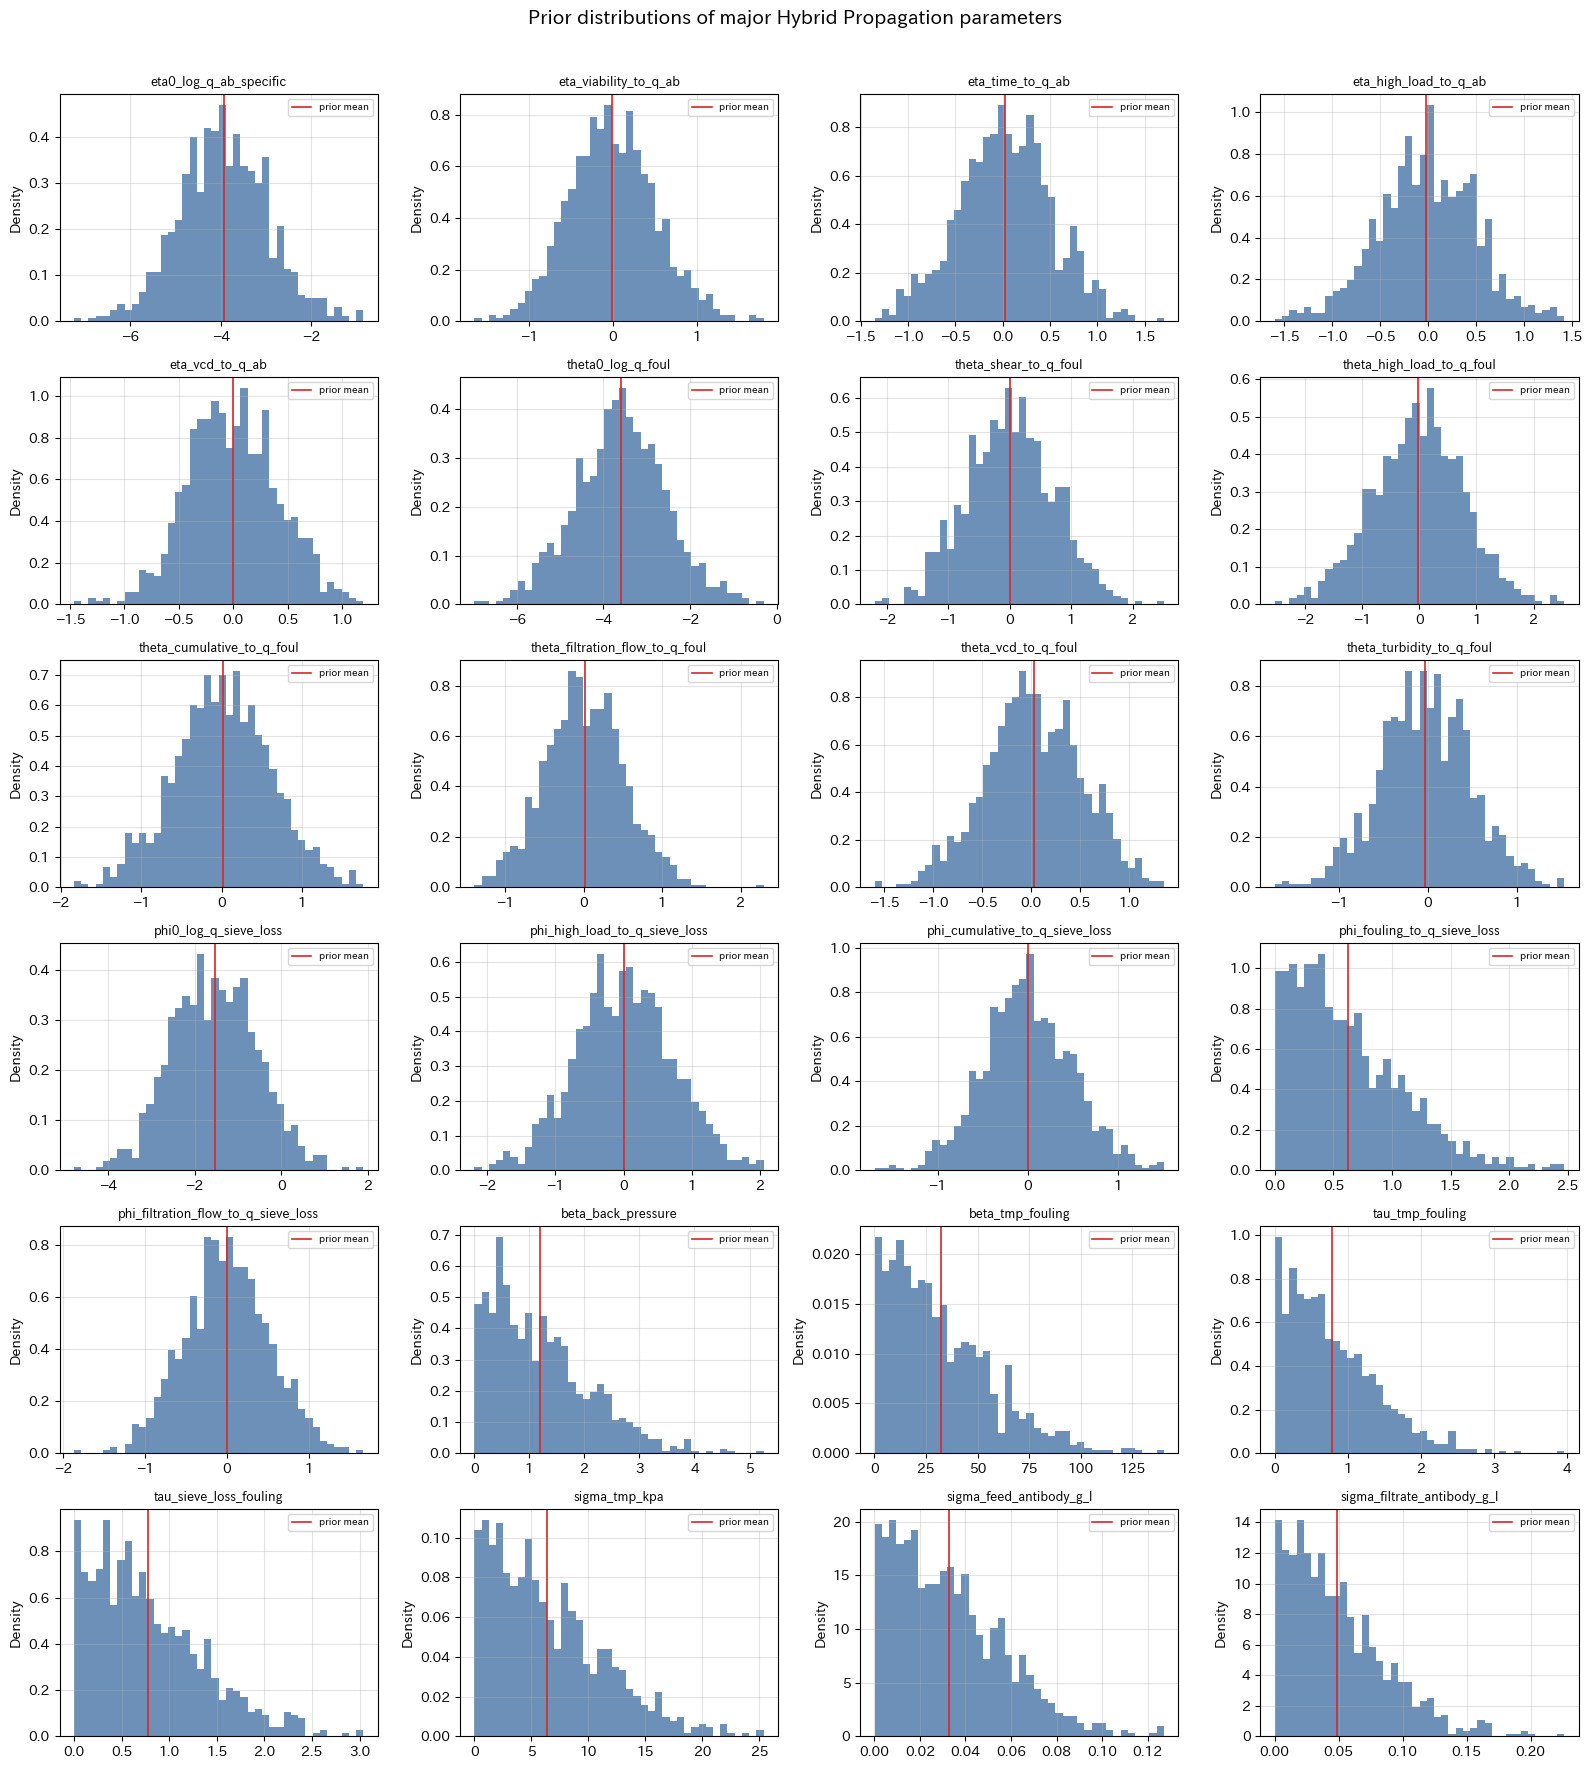

In [7]:
# このセルは、観測データを使わずに事前分布から予測を生成し、モデルのスケールと事前分布の形状を確認する。
if PYMC_AVAILABLE:
    with model:
        prior_pred = pm.sample_prior_predictive(samples=100, random_seed=random_seed)
    print(prior_pred)

    # MCMC前に、主要パラメータへ置いた事前分布そのものをヒストグラムで表示する。
    prior_variables = [
        "eta0_log_q_ab_specific", "eta_viability_to_q_ab", "eta_time_to_q_ab", "eta_high_load_to_q_ab", "eta_vcd_to_q_ab",
        "theta0_log_q_foul", "theta_shear_to_q_foul", "theta_high_load_to_q_foul", "theta_cumulative_to_q_foul",
        "theta_filtration_flow_to_q_foul", "theta_vcd_to_q_foul", "theta_turbidity_to_q_foul",
        "phi0_log_q_sieve_loss", "phi_high_load_to_q_sieve_loss", "phi_cumulative_to_q_sieve_loss",
        "phi_fouling_to_q_sieve_loss", "phi_filtration_flow_to_q_sieve_loss",
        "beta_back_pressure", "beta_tmp_fouling", "tau_tmp_fouling", "tau_sieve_loss_fouling",
        "sigma_tmp_kpa", "sigma_feed_antibody_g_l", "sigma_filtrate_antibody_g_l",
    ]
    available_prior_variables = [name for name in prior_variables if name in model.named_vars]
    prior_samples = pm.draw(
        [model[name] for name in available_prior_variables],
        draws=1000,
        random_seed=random_seed,
    )

    n_columns = 4
    n_rows = int(np.ceil(len(available_prior_variables) / n_columns))
    figure, axes = plt.subplots(n_rows, n_columns, figsize=(16, 3.0 * n_rows), squeeze=False)
    for axis, name, samples in zip(axes.flat, available_prior_variables, prior_samples):
        values = np.asarray(samples).reshape(-1)
        axis.hist(values, bins=40, density=True, color="#4C78A8", alpha=0.82)
        axis.axvline(np.mean(values), color="#D62728", linewidth=1.2, label="prior mean")
        axis.set_title(name, fontsize=9)
        axis.set_ylabel("Density")
        axis.grid(alpha=0.35)
        axis.legend(fontsize=7)
    for axis in axes.flat[len(available_prior_variables):]:
        axis.set_visible(False)
    figure.suptitle("Prior distributions of major Hybrid Propagation parameters", fontsize=14, fontweight="bold")
    figure.tight_layout(rect=(0, 0, 1, 0.97))
    plt.show()
else:
    prior_pred = None

### セルの役割

このセルは、データをまだ使わずにモデルの事前分布から予測を生成する。機構式やrateのスケールが現実的かを、MCMC前に確認するための安全確認である。

## 5. MCMCサンプリング

このセクションでは、q-rate、runごとの初期状態、観測ノイズなどの事後分布をMCMCで推定する。`RUN_SAMPLING=True`なら新たに推定し、`False`なら既存NetCDFを読み込んで要約と可視化だけを再実行する。

短時間の動作確認では`draws`、`tune`、`chains`を小さくし、本番評価では十分なサンプル数へ戻す。実行後は`divergences`、R-hat、ESS、トレースを確認する。

In [8]:
# このセルは、PyMCのMCMCを実行し、事後分布をInferenceData/NetCDFとして保存または再読込する。
# RUN_SAMPLING=Falseの場合は、既存NetCDFを使って後続の要約・可視化だけを行う。
idata_path = OUTPUT_DIR / "akls_hybrid_propagation_v1_idata.nc"

if not PYMC_AVAILABLE:
    raise RuntimeError(f"PyMCが利用できません。先頭セルの%pip installを実行してください。詳細: {PM_IMPORT_ERROR!r}")

if RUN_SAMPLING:
    with model:
        sample_kwargs = dict(
            draws=draws,
            tune=tune,
            chains=chains,
            cores=cores,
            target_accept=target_accept,
            random_seed=random_seed,
            return_inferencedata=True,
            nuts_sampler_kwargs={
            "chain_method": "parallel"
        },  # CPUで複数チェーンを並列化する場合
        # GPUが使える場合は "vectorized" が最速になることが多いです
    )
        if NUTS_SAMPLER == "numpyro":
            sample_kwargs["nuts_sampler"] = "numpyro"
        idata = pm.sample(**sample_kwargs)
    try:
        az.to_netcdf(idata, idata_path)
        print(f"InferenceData saved: {idata_path}")
    except Exception as exc:
        warnings.warn(f"NetCDF保存をスキップしました: {exc}")
elif idata_path.exists():
    idata = az.from_netcdf(idata_path)
    print(f"InferenceData loaded: {idata_path}")
else:
    raise RuntimeError("RUN_SAMPLING=False ですが既存NetCDFがありません。")

if hasattr(idata, "sample_stats") and "diverging" in idata.sample_stats:
    print("divergences:", int(idata.sample_stats["diverging"].sum()))

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


InferenceData saved: d:\Users\a1049994\CVC\AKLS\akls_hybrid_propagation_v1_results\akls_hybrid_propagation_v1_idata.nc
divergences: 0


### セルの役割

このセルは、PyMCモデルをMCMCでサンプリングし、推定結果を`InferenceData`としてNetCDFに保存する。既存ファイルを使う設定では、サンプリングを省略して保存済み結果を読み込む。

## 6. パラメータ要約と予測区間

MCMCで得たchainとdrawを統合し、主要なq-rate係数の要約表と、観測行ごとの予測テーブルを作成する。

予測テーブルの`_mean`は事後平均、`_lower`と`_upper`は指定した信用区間の下限・上限である。区間には、rateパラメータ、初期状態、潜在状態、観測ノイズの不確実性が伝播している。

`q_rates.csv`は各遷移区間のrateを確認するための出力であり、単なる最終予測だけでなく、どの時点・条件で抗体産生、fouling、sieving低下が速くなったかを診断するために使う。

In [9]:
# このセルは、事後サンプルを平均・信用区間へ集計し、予測表とパラメータ要約CSVを作成する。
def posterior_array(idata, var_name: str) -> np.ndarray:
    # 指定変数のchainとdrawをsample軸へ結合し、集計しやすい配列へ変換する。
    data_array = idata.posterior[var_name].stack(sample=("chain", "draw"))
    non_sample_dims = [dimension for dimension in data_array.dims if dimension != "sample"]
    if non_sample_dims:
        data_array = data_array.transpose(*non_sample_dims, "sample")
    array = np.asarray(data_array.values)
    if array.ndim == 1:
        array = array.reshape(1, -1)
    return array


def posterior_interval(idata, var_name: str, hdi_prob: float = 0.95):
    # 事後サンプルから平均、指定確率の下限、上限を計算する。
    array = posterior_array(idata, var_name)
    lower = (1.0 - hdi_prob) / 2.0
    upper = 1.0 - lower
    return array.mean(axis=-1), np.quantile(array, lower, axis=-1), np.quantile(array, upper, axis=-1)


def prediction_table(idata, data: dict, hdi_prob: float = 0.95) -> pd.DataFrame:
    # 上流状態からFiltrate抗体濃度までを、元の観測行に結合する。
    result = data["df"].copy()
    variables = [
        "feed_antibody_state_g_l",
        "fouling_state",
        "tmp_pred_kpa",
        "transmission_pred_pct",
        "filtrate_antibody_pred_g_l",
    ]
    for var in variables:
        mean, lower, upper = posterior_interval(idata, var, hdi_prob)
        result[f"{var}_mean"] = mean
        result[f"{var}_lower"] = lower
        result[f"{var}_upper"] = upper
    return result

summary_vars = [
    "eta0_log_q_ab_specific", "eta_viability_to_q_ab", "eta_time_to_q_ab", "eta_high_load_to_q_ab", "eta_vcd_to_q_ab",
    "theta0_log_q_foul", "theta_shear_to_q_foul", "theta_high_load_to_q_foul", "theta_cumulative_to_q_foul", "theta_filtration_flow_to_q_foul", "theta_vcd_to_q_foul", "theta_turbidity_to_q_foul",
    "phi0_log_q_sieve_loss", "phi_high_load_to_q_sieve_loss", "phi_cumulative_to_q_sieve_loss", "phi_fouling_to_q_sieve_loss", "phi_filtration_flow_to_q_sieve_loss",
    "beta_back_pressure", "beta_tmp_fouling", "sigma_tmp_kpa", "sigma_feed_antibody_g_l", "sigma_filtrate_antibody_g_l",
]
summary = az.summary(idata, var_names=[v for v in summary_vars if v in idata.posterior], hdi_prob=hdi_prob)
pred = prediction_table(idata, data, hdi_prob=hdi_prob)

summary_path = OUTPUT_DIR / "akls_hybrid_propagation_v1_parameter_summary.csv"
pred_path = OUTPUT_DIR / "akls_hybrid_propagation_v1_predictions.csv"
summary.to_csv(summary_path, encoding="utf-8-sig")
pred.to_csv(pred_path, index=False, encoding="utf-8-sig")

display(summary)
print("predictions:", pred.shape, pred_path)
display(pred.head())

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
eta0_log_q_ab_specific,-7.558,0.179,-7.933,-7.233,0.013,0.007,179.0,468.0,1.02
eta_viability_to_q_ab,-0.222,0.240,-0.691,0.250,0.015,0.007,258.0,613.0,1.02
eta_time_to_q_ab,-0.126,0.278,-0.648,0.447,0.021,0.010,177.0,521.0,1.01
eta_high_load_to_q_ab,0.610,0.270,0.095,1.159,0.022,0.010,152.0,336.0,1.02
eta_vcd_to_q_ab,0.411,0.197,0.045,0.799,0.012,0.005,280.0,744.0,1.02
theta0_log_q_foul,-1.746,0.439,-2.627,-0.858,0.043,0.028,103.0,87.0,1.04
theta_shear_to_q_foul,0.007,0.182,-0.389,0.194,0.027,0.027,55.0,112.0,1.06
theta_high_load_to_q_foul,-1.187,0.498,-2.162,-0.221,0.038,0.020,162.0,294.0,1.02
theta_cumulative_to_q_foul,-0.526,0.209,-0.950,-0.124,0.017,0.009,152.0,330.0,1.03
theta_filtration_flow_to_q_foul,0.759,0.092,0.583,0.936,0.009,0.004,108.0,146.0,1.03


predictions: (186, 85) d:\Users\a1049994\CVC\AKLS\akls_hybrid_propagation_v1_results\akls_hybrid_propagation_v1_predictions.csv


,row_label,elapsed_h,sampling_volume,circulation_ml_min,circulation_rpm,filtration_ul_min,Flow rate | cm,Flow rate | time,cumulative_filtrate_l_m2,Filtration amount | Cumulative,pressure_in_kPa,pressure_out_kPa,back_pressure_kpa,tmp_kpa,temperature_C,vcd_cho_1e5_cells_ml,viability_cho_pct,vcd_matsuda_1e5_cells_ml,viability_matsuda_pct,glc_g_L,glu_mmol_L,gln_mmol_L,lln_g_L,feed_antibody_g_l,filtrate_antibody_g_l,transmission_pct,antibody_g_m2_1,antibody_g_m2_2,cumulative_transmission_pct,turbidity_feed_od600,turbidity_filtrate_od600,turbidity_plate_reader,ldh_activity_unit,LDH,LDH_2,LDH_3,LDH_4,LDH_5,source_file,run_id,shear_rate_lmh,lmh_group,condition_label,record_sheet,Date removed,Time,flow_pct_initial,Flow rate | %,vcd_1e5_cells_ml,viability_pct,LDH_6,filtration_flow_cumulative_pct,flow_ratio_pct,Turbidity OD600,row_number,vcd_driver,viability_driver_pct,vcd_interp,viability_interp_pct,turbidity_interp,cumulative_filtrate_interp,back_pressure_interp,filtration_flow_interp,circulation_flow_interp,back_pressure_load,tmp_obs_available,feed_ab_obs_available,filtrate_ab_obs_available,transmission_obs_available,run_idx,feed_antibody_state_g_l_mean,feed_antibody_state_g_l_lower,feed_antibody_state_g_l_upper,fouling_state_mean,fouling_state_lower,fouling_state_upper,tmp_pred_kpa_mean,tmp_pred_kpa_lower,tmp_pred_kpa_upper,transmission_pred_pct_mean,transmission_pred_pct_lower,transmission_pred_pct_upper,filtrate_antibody_pred_g_l_mean,filtrate_antibody_pred_g_l_lower,filtrate_antibody_pred_g_l_upper
0,Filtration start,0.0,"2.0, 0.0",8.05,920.0,NaN,NaN,NaN,0.000000,NaN,1.5,-1.0,-0.4,0.7,9.4,146.0,94.8,NaN,NaN,3.14,0.48,0.32,0.50,0.496091,NaN,NaN,NaN,NaN,NaN,1.225,NaN,1.2252,497.992,574.005,535.9985,53.749308,NaN,0.31,01_Perfusion-shear_rate_500_LMH_1.xlsx,01_Perfusion-shear_rate_500_LMH_1,500.0,1.0,500 shear / LMH 1,01-record,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,146.0,94.8,146.0,94.80,1.225,0.000000,-0.4,5.110792,8.05,0.4,True,True,False,False,0,0.501135,0.498751,0.503556,0.000000,0.000000,0.000000,0.457073,0.412309,0.495790,99.537502,99.129853,99.813851,0.498817,0.496060,0.501425
1,NaN,2.0,NaN,8.05,950.0,NaN,NaN,NaN,NaN,NaN,1.3,-1.3,-0.8,0.8,4.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,01_Perfusion-shear_rate_500_LMH_1.xlsx,01_Perfusion-shear_rate_500_LMH_1,500.0,1.0,500 shear / LMH 1,01-record,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,141.5,94.15,1.225,8.943885,-0.8,5.110792,8.05,0.8,True,False,False,False,0,0.501153,0.498772,0.503569,0.021531,0.006947,0.052964,0.857244,0.812807,0.895959,99.534483,99.126349,99.812252,0.498820,0.496065,0.501429
2,NaN,17.5,"1.5, 1.5",8.05,960.0,5.110792,2.3,0.566111,17.887771,101.693805,1.4,-1.3,-1.0,1.1,3.6,137.0,93.5,NaN,NaN,3.16,0.50,0.28,0.56,0.494442,0.488015,98.700124,8.859209,8.729494,98.535814,NaN,0.006,0.0055,610.580,740.681,675.6305,91.995299,NaN,NaN,01_Perfusion-shear_rate_500_LMH_1.xlsx,01_Perfusion-shear_rate_500_LMH_1,500.0,1.0,500 shear / LMH 1,01-record,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,137.0,93.5,137.0,93.50,1.225,17.887771,-1.0,5.110792,8.05,1.0,True,True,True,True,0,0.501267,0.498908,0.503623,0.146069,0.039462,0.374326,1.057915,1.014361,1.096103,99.511238,99.085587,99.801853,0.498817,0.496016,0.501397
3,NaN,24.0,"1.5, 1.5",8.05,950.0,4.962856,2.0,0.506944,24.435642,101.295191,1.3,-1.3,-1.0,1.1,3.5,153.0,94.5,NaN,NaN,3.08,0.50,0.28,0.58,0.495550,0.487018,98.278103,3.241170,3.192192,98.523241,NaN,0.007,0.0067,NaN,NaN,NaN,NaN,NaN,NaN,01_Perfusion-shear_rate_500_LMH_1.xlsx,01_Perfusion-shear_rate_500_LMH_1,500.0,1.0,500 shear / LMH 1,01-record,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,153.0,94.5,153.0,94.50,1.225,24.435642,-1.0,4.962856,8.05,1.0,True,True,True,True,0,0.501330,0.498992,0.503675,0.215047,0.063129,0.540054,1.058379,1.015175,1.096199,99.501310,99.069816,99.797979,0.498830,0.496033,0.501416
4,NaN,42.5,"1.5, 1.5",8.05,960.0,5.086035,2.5,0.618333,43.026090,100.720825,1.4,-1.3,-1.0,1.1,3.3,150.0,94.3,NaN

### セルの役割

このセルは、chainとdrawを整理して事後平均・信用区間を計算し、全時点の状態予測と主要パラメータ要約をCSVに出力する。`prediction_table`は上流状態から下流目的変数までを1つの表にまとめる。

In [10]:
# このセルは、各遷移区間のq-rateと信用区間を表にして保存する。
def rate_table(idata, data: dict, hdi_prob: float = 0.95) -> pd.DataFrame:
    # q_ab、q_foul、q_sieve_lossの区間別事後予測をtransition_dfへ追加する。
    result = data["transition_df"].copy()
    variables = ["q_ab_specific_g_l_day", "q_foul_per_day", "q_sieve_loss_logit_per_day"]
    for var in variables:
        mean, lower, upper = posterior_interval(idata, var, hdi_prob)
        result[f"{var}_mean"] = mean
        result[f"{var}_lower"] = lower
        result[f"{var}_upper"] = upper
    return result

rates = rate_table(idata, data, hdi_prob=hdi_prob)
rates_path = OUTPUT_DIR / "akls_hybrid_propagation_v1_q_rates.csv"
rates.to_csv(rates_path, index=False, encoding="utf-8-sig")
print("q-rate table:", rates.shape, rates_path)
display(rates.head())

q-rate table: (179, 23) d:\Users\a1049994\CVC\AKLS\akls_hybrid_propagation_v1_results\akls_hybrid_propagation_v1_q_rates.csv


,run,run_idx,from_obs,to_obs,dt_days,elapsed_mid_h,log_shear,high_load,cum_mid,filtration_flow_mid,circulation_flow_mid,vcd_mid,viability_mid_pct,turbidity_mid,q_ab_specific_g_l_day_mean,q_ab_specific_g_l_day_lower,q_ab_specific_g_l_day_upper,q_foul_per_day_mean,q_foul_per_day_lower,q_foul_per_day_upper,q_sieve_loss_logit_per_day_mean,q_sieve_loss_logit_per_day_lower,q_sieve_loss_logit_per_day_upper
0,01_Perfusion-shear_rate_500_LMH_1,0,0,1,0.083333,1.00,-0.693147,0.0,4.471943,5.110792,8.05,143.75,94.475,1.225,0.000259,0.000066,0.000620,0.258368,0.083361,0.635567,0.081695,0.025124,0.174942
1,01_Perfusion-shear_rate_500_LMH_1,0,1,2,0.645833,9.75,-0.693147,0.0,13.415828,5.110792,8.05,139.25,93.825,1.225,0.000212,0.000043,0.000579,0.192833,0.050086,0.498848,0.078438,0.024540,0.166709
2,01_Perfusion-shear_rate_500_LMH_1,0,2,3,0.270833,20.75,-0.693147,0.0,21.161706,5.036824,8.05,145.00,94.000,1.225,0.000270,0.000078,0.000608,0.254688,0.087474,0.612535,0.076570,0.025251,0.159454
3,01_Perfusion-shear_rate_500_LMH_1,0,3,4,0.770833,33.25,-0.693147,0.0,33.730866,5.024445,8.05,151.50,94.400,1.225,0.000364,0.000143,0.000679,0.352469,0.147270,0.792146,0.073039,0.025147,0.147985
4,01_Perfusion-shear_rate_500_LMH_1,0,4,5,0.958333,54.00,-0.693147,0.0,48.961817,5.068859,8.05,153.00,94.150,1.225,0.000386,0.000169,0.000677,0.361866,0.157570,0.799733,0.074192,0.030655,0.139340


### セルの役割

このセルは、遷移区間ごとの`q_ab`、`q_foul`、`q_sieve_loss`を表形式にして保存する。最終値だけでなく、プロセスのどの区間でrateが変化したかを確認するための診断出力である。

## 7. 診断プロット

各runについて、機構式の上流から下流までを同じ時間軸で確認する。

1. **Feed抗体濃度**: `q_ab`で伝播した抗体産生状態
2. **Fouling state**: `q_foul`を累積した潜在膜状態
3. **TMP**: 背圧負荷とfoulingから得た圧力予測
4. **Transmission**: `q_sieve_loss`で低下する膜透過性
5. **Filtrate抗体濃度**: `Feed antibody × Transmission`で生成された目的変数

赤線は予測平均、帯は信用区間、青点は実測値である。系統的なずれ、異常に広い区間、上流のずれが下流へ伝播している箇所を確認する。

In [11]:
# このセルは、runごとに予測平均・信用区間・実測値を重ねた診断PDFを作成する。
def make_diagnostic_plots(idata, data: dict, out_dir: Path, hdi_prob: float = 0.95) -> Path:
    # 5種類の状態・目的変数について、run別の診断ページを作成してPDFへ保存する。
    work = data["df"].copy()
    time_values = work["elapsed_h"].to_numpy(float)
    variables = [
        "feed_antibody_state_g_l",
        "fouling_state",
        "tmp_pred_kpa",
        "transmission_pred_pct",
        "filtrate_antibody_pred_g_l",
    ]
    intervals = {var: posterior_interval(idata, var, hdi_prob) for var in variables}
    interval_label = f"{int(hdi_prob * 100)}%信用区間"
    pdf_path = out_dir / "akls_hybrid_propagation_v1_diagnostics.pdf"
    with PdfPages(pdf_path) as pdf:
        for run in data["runs"]:
            mask = work["run_id"].eq(run).to_numpy()
            subset = work.loc[mask]
            x = time_values[mask]
            fig, axes = plt.subplots(5, 1, figsize=(11.69, 8.27), sharex=True)
            title = f"Hybrid Propagation Model v1: run {run} / {subset['condition_label'].iloc[0]}"
            fig.suptitle(title, fontsize=13, fontweight="bold")
            panels = [
                ("feed_antibody_state_g_l", "Feed抗体濃度", "g/L", "feed_antibody_g_l"),
                ("fouling_state", "潜在Fouling状態", "F", None),
                ("tmp_pred_kpa", "TMP", "kPa", "tmp_kpa"),
                ("transmission_pred_pct", "Transmission", "%", "transmission_pct"),
                ("filtrate_antibody_pred_g_l", "Filtrate抗体濃度", "g/L", "filtrate_antibody_g_l"),
            ]
            for ax, (var, label, ylabel, obs_col) in zip(axes, panels):
                mean, lower, upper = intervals[var]
                ax.fill_between(x, lower[mask], upper[mask], alpha=0.25, label=interval_label)
                ax.plot(x, mean[mask], linewidth=2, label=label)
                if obs_col is not None and obs_col in subset.columns:
                    obs_mask = subset[obs_col].notna().to_numpy()
                    ax.scatter(x[obs_mask], subset.loc[obs_mask, obs_col], s=18, label="実測", zorder=4)
                ax.set_ylabel(ylabel)
                ax.grid(alpha=0.6)
                ax.legend(loc="best", fontsize=8)
            axes[-1].set_xlabel("経過時間 h")
            fig.tight_layout(rect=(0, 0.02, 1, 0.95))
            pdf.savefig(fig)
            plt.close(fig)
    return pdf_path

pdf_path = make_diagnostic_plots(idata, data, OUTPUT_DIR, hdi_prob=hdi_prob)
print("diagnostic PDF:", pdf_path)

diagnostic PDF: d:\Users\a1049994\CVC\AKLS\akls_hybrid_propagation_v1_results\akls_hybrid_propagation_v1_diagnostics.pdf


### セルの役割

このセルは、各runの5つの状態・予測値をPDFへ描画する。平均線、信用区間、実測点を同じ図に重ね、上流のずれが下流のFiltrate antibody予測へどう伝播したかを目視確認する。

In [ ]:
# このセルは、Dropdownで選択したrunだけをNotebook上に再描画する。
# インタラクティブ表示。ipywidgetsがない環境ではPDFを確認してください。
try:
    import ipywidgets as widgets
    from IPython.display import display

    run_widget = widgets.Dropdown(options=list(data["runs"]), description="run")

    def show_run(run):
        # 選択runの5系列について、事後平均・信用区間・実測値を表示する。
        work = data["df"]
        mask = work["run_id"].eq(run).to_numpy()
        subset = work.loc[mask]
        x = subset["elapsed_h"].to_numpy(float)
        variables = [
            ("feed_antibody_state_g_l", "Feed抗体濃度", "g/L", "feed_antibody_g_l"),
            ("fouling_state", "潜在Fouling状態", "F", None),
            ("tmp_pred_kpa", "TMP", "kPa", "tmp_kpa"),
            ("transmission_pred_pct", "Transmission", "%", "transmission_pct"),
            ("filtrate_antibody_pred_g_l", "Filtrate抗体濃度", "g/L", "filtrate_antibody_g_l"),
        ]
        fig, axes = plt.subplots(5, 1, figsize=(11, 13), sharex=True)
        for ax, (var, label, ylabel, obs_col) in zip(axes, variables):
            mean, lower, upper = posterior_interval(idata, var, hdi_prob)
            ax.fill_between(x, lower[mask], upper[mask], alpha=0.25, label=f"{int(hdi_prob*100)}%信用区間")
            ax.plot(x, mean[mask], linewidth=2, label=label)
            if obs_col is not None and obs_col in subset:
                obs_mask = subset[obs_col].notna().to_numpy()
                ax.scatter(x[obs_mask], subset.loc[obs_mask, obs_col], s=18, label="実測", zorder=4)
            ax.set_ylabel(ylabel)
            ax.grid(alpha=0.6)
            ax.legend(loc="best")
        axes[-1].set_xlabel("経過時間 h")
        fig.suptitle(f"AKLS Hybrid Propagation Model v1: run {run}")
        fig.tight_layout()
        plt.show()

    out = widgets.interactive_output(show_run, {"run": run_widget})
    display(run_widget, out)
except Exception as exc:
    print("ipywidgets表示をスキップしました:", exc)

Dropdown(description='run', options=('01_Perfusion-shear_rate_500_LMH_1', '04_Perfusion-shear_rate_900_LMH_1',…

Output()

### セルの役割

このセルは、Dropdownでrunを選び、同じ5つの系列をNotebook上で再表示する。PDFが固定的な出力、widgetがrunごとの対話的な確認画面に相当する。

## 8. このv1で明らかになること

このNotebookの最終的な目的は、単一の予測値を出すことではなく、プロセスのどのrateが下流の予測を支配しているかを確率的に確認することである。

- **抗体産生rate `q_ab`**: feed側抗体濃度の時間推移を説明できるか
- **膜ファウリングrate `q_foul`**: TMP上昇の時間推移と整合するか
- **Transmission低下rate `q_sieve_loss`**: 膜透過性とFiltrate抗体濃度の低下を説明できるか
- **信用区間**: データ不足やモデル構造の不確実性がどこに現れるか

v1ではVCD・Viabilityは観測済み外生ドライバーであり、細胞増殖・死滅そのもののPropagationは行わない。次段階では細胞状態のODEや代謝物収支を追加することで、より完全なHybrid Propagation Modelへ拡張できる。